# Three-Label Model Comparisons

This notebook compares four configurations for a 3-label SFH setup:

- log no prior (`log-model`)
- log with prior (`log-prior-model`)
- linear bounds no prior (`linear-model`)
- linear bounds with prior (`linear-bounds-model`)

For each configuration, we will plot:

1. true label vs predicted label (all three labels)
2. model-predicted vs true flux at wavelength pixel 300, shown against each label

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add code/src so CannonModel can be imported from this notebook.
repo_root = Path('/home/vmehta/honours-project')
src_path = repo_root / 'code' / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from AnniesLasso.thecannon.model import CannonModel

plt.style.use('thesis')

In [6]:
# Set this to your 3-label run directory name under /avatar/vmehta.
run_name = 'sfh_1000_3bins_20260323_155219'
base_dir = Path('/avatar/vmehta') / run_name

# Folder and behavior map for each configuration.
CONFIGS = {
    'log-model': {
        'folder': 'log-model',
        'model_labels_are_log10': True,
    },
    'log-prior-model': {
        'folder': 'log-prior-model',
        'model_labels_are_log10': True,
    },
    'linear-model': {
        'folder': 'linear-model',
        'model_labels_are_log10': False,
    },
    'linear-prior-model': {
        'folder': 'linear-prior-model',
        'model_labels_are_log10': False,
    },
}

label_names = ['Label 1', 'Label 2', 'Label 3']
default_snr = 1000
flux_pixel = 300

In [7]:
def _paths_for(config_name, snr):
    cfg = CONFIGS[config_name]
    folder = base_dir / cfg['folder']
    pred_path = folder / f'snr{snr}_pred.npy'
    true_path = folder / f'snr{snr}_true.npy'
    model_path = folder / f'snr{snr}_model.pkl'
    return pred_path, true_path, model_path


def load_pred_true(config_name, snr=default_snr):
    pred_path, true_path, _ = _paths_for(config_name, snr)

    if not pred_path.exists() or not true_path.exists():
        raise FileNotFoundError(
            f'Missing arrays for {config_name}: {pred_path.name} and/or {true_path.name}')

    pred = np.load(pred_path)
    true = np.load(true_path)

    if pred.shape[1] != 3 or true.shape[1] != 3:
        raise ValueError(f'Expected 3 labels, got pred={pred.shape}, true={true.shape}')

    return pred, true


def plot_true_vs_pred(config_name, snr=default_snr):
    pred, true = load_pred_true(config_name, snr=snr)

    fig, ax = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True, constrained_layout=True)
    for i in range(3):
        ax[i].plot(true[:, i], pred[:, i], '.', alpha=0.5, markersize=5)
        lo = min(true[:, i].min(), pred[:, i].min())
        hi = max(true[:, i].max(), pred[:, i].max())
        ax[i].plot([lo, hi], [lo, hi], 'k--', linewidth=1)
        ax[i].set_title(label_names[i])
        ax[i].set_xlabel('True')

    ax[0].set_ylabel('Predicted')
    fig.suptitle(f'{config_name}: True vs Predicted Labels (SNR={snr})')
    plt.show()


def load_model(config_name, snr=default_snr):
    _, _, model_path = _paths_for(config_name, snr)
    if not model_path.exists():
        raise FileNotFoundError(f'Missing model file for {config_name}: {model_path.name}')
    return CannonModel.read(str(model_path))


def plot_flux_at_pixel(config_name, snr=default_snr, pixel=flux_pixel):
    cfg = CONFIGS[config_name]
    model = load_model(config_name, snr=snr)

    labels_x = np.array(model.training_set_labels, copy=True)
    if cfg['model_labels_are_log10']:
        labels_x = np.power(10.0, labels_x)

    true_flux = model.training_set_flux[:, pixel]
    model_flux = model(model.training_set_labels)[:, pixel]

    fig, ax = plt.subplots(1, 3, figsize=(13, 4), sharey=True, constrained_layout=True)
    for i in range(3):
        ax[i].plot(labels_x[:, i], true_flux, '.', alpha=0.5, markersize=4, label='True flux')
        ax[i].plot(labels_x[:, i], model_flux, '.', alpha=0.5, markersize=4, label='Model flux')
        ax[i].set_title(label_names[i])
        ax[i].set_xlabel('Label value')

    ax[0].set_ylabel(f'Flux at pixel {pixel}')
    ax[-1].legend(loc='best')
    fig.suptitle(f'{config_name}: Flux Comparison at Pixel {pixel} (SNR={snr})')
    plt.show()


--- log-model ---


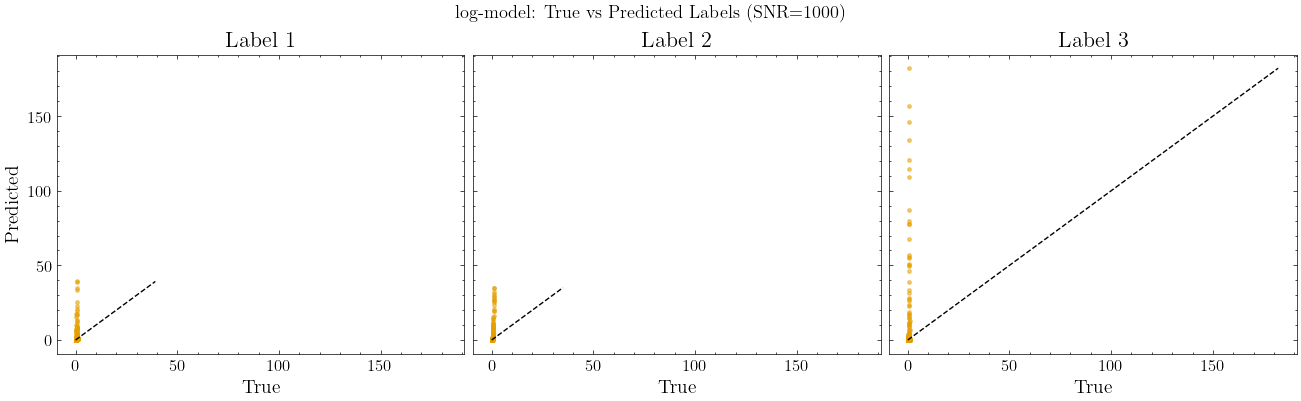

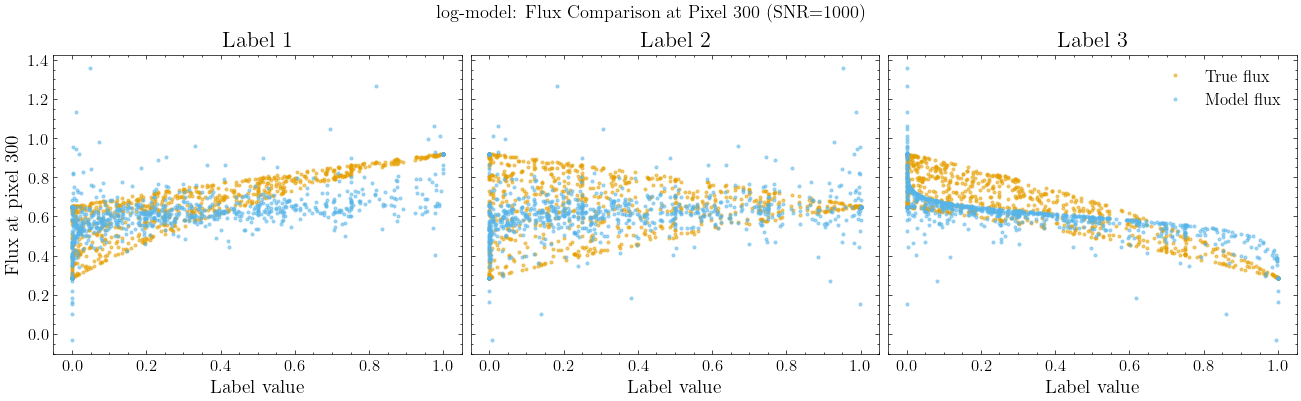


--- log-prior-model ---


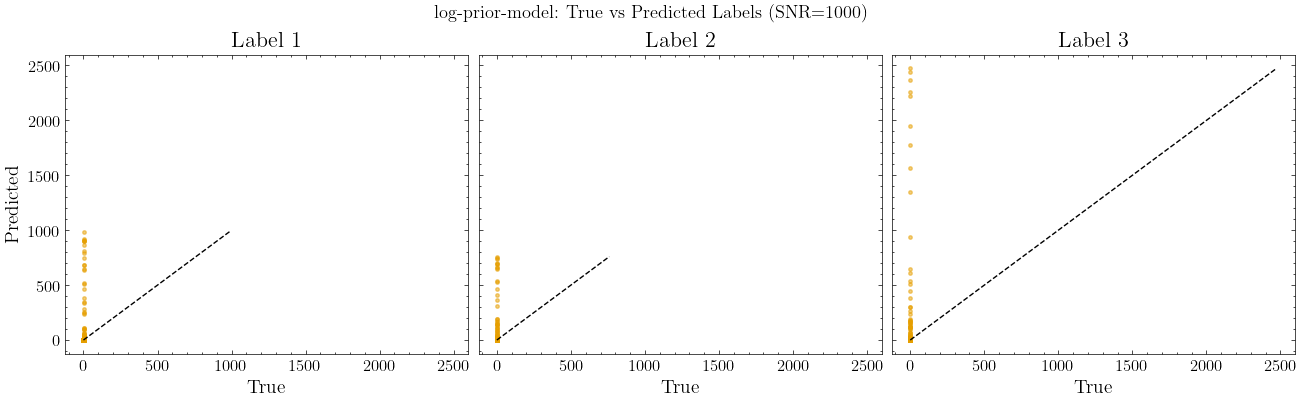

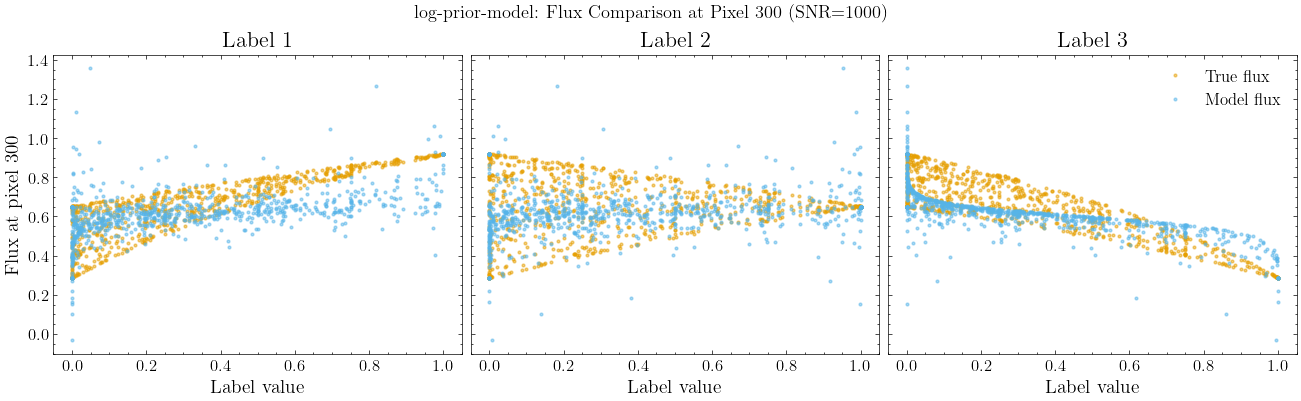


--- linear-model ---


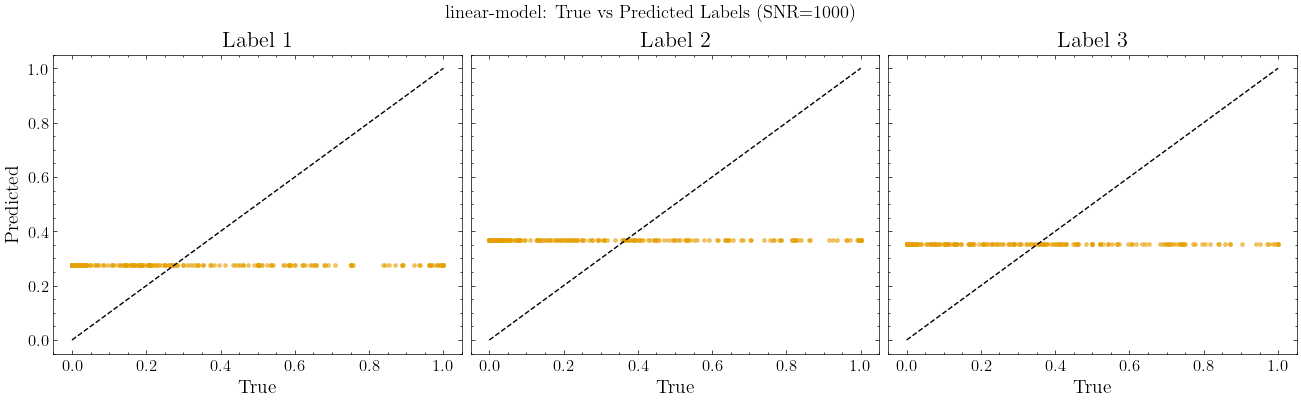

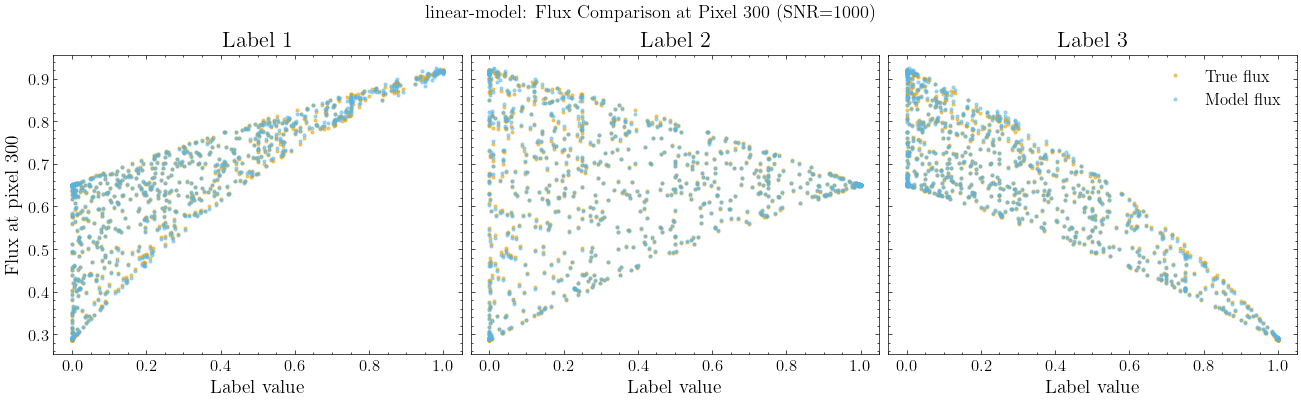


--- linear-prior-model ---


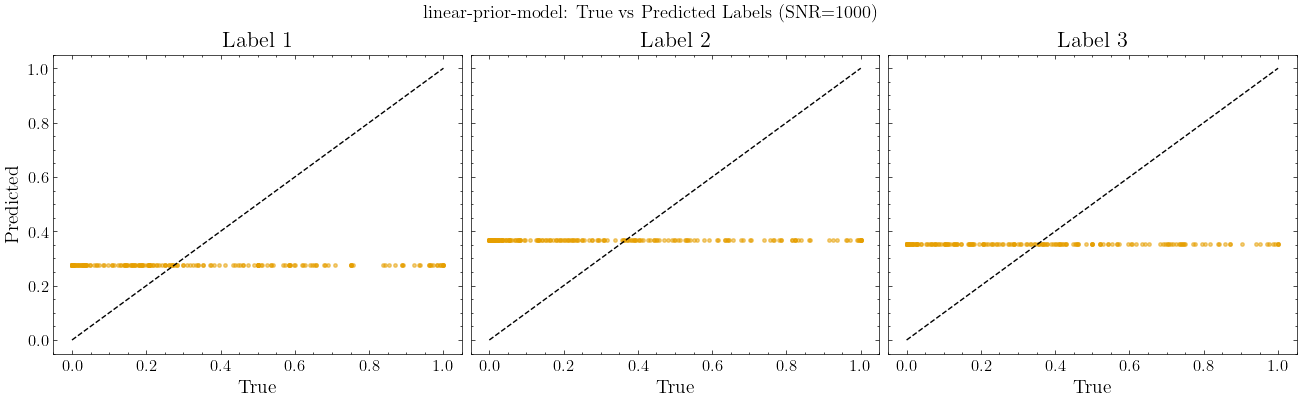

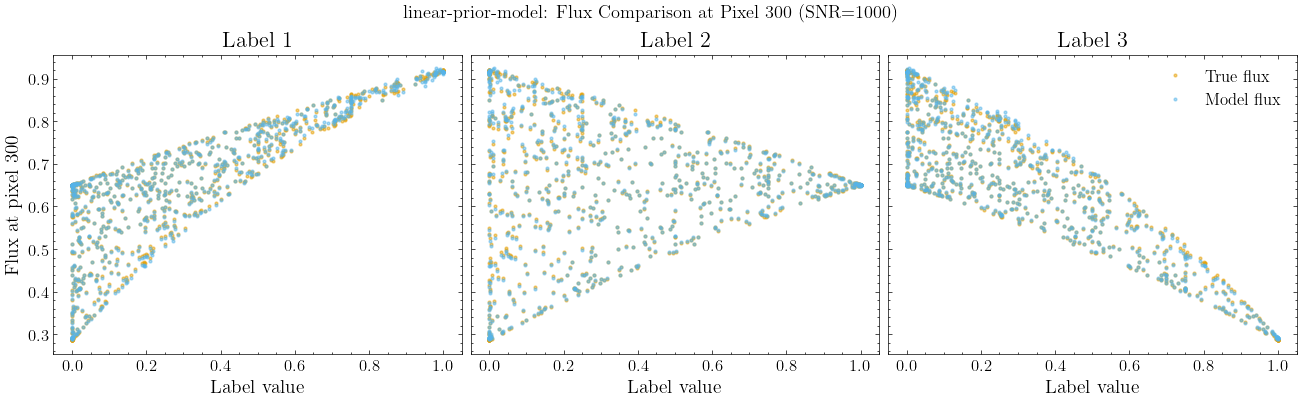

In [8]:
# Run this cell after setting run_name and folder names above.
for cfg_name in CONFIGS:
    print(f'\n--- {cfg_name} ---')
    plot_true_vs_pred(cfg_name, snr=default_snr)
    plot_flux_at_pixel(cfg_name, snr=default_snr, pixel=flux_pixel)

## Diagnostics: Why Labels Collapse

These cells help diagnose why linear bounded runs can collapse toward central label values.

1. Coefficient separability and conditioning of the linear label terms.
2. Inversion behavior on the model's own training spectra (where generalization is not the issue).

In [9]:
def diagnose_coefficients(config_name, snr=default_snr):
    """Report linear-term separability and conditioning for a model config."""
    model = load_model(config_name, snr=snr)

    # theta columns: [constant, linear terms..., quadratic/cross terms...]
    # For 3 labels, the 3 linear terms are columns 1..3.
    linear_theta = np.asarray(model.theta[:, 1:4], dtype=float)

    corr = np.corrcoef(linear_theta.T)
    gram = linear_theta.T @ linear_theta
    cond_gram = np.linalg.cond(gram)

    print(f"\n=== {config_name} | coefficient diagnostics ===")
    print("Linear-term correlation matrix:")
    print(np.array2string(corr, precision=3, suppress_small=True))
    print(f"cond(Theta_lin^T Theta_lin) = {cond_gram:.3e}")

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, constrained_layout=True)
    for i in range(3):
        ax[i].plot(model.dispersion, linear_theta[:, i], linewidth=0.4, color='k')
        ax[i].set_title(f'{label_names[i]} linear coeff')
        ax[i].set_xlabel('Wavelength')
    ax[0].set_ylabel('Coefficient value')
    fig.suptitle(f'{config_name}: Linear Coefficient Vectors')
    plt.show()


=== log-model | coefficient diagnostics ===
Linear-term correlation matrix:
[[ 1.     0.759 -0.982]
 [ 0.759  1.    -0.817]
 [-0.982 -0.817  1.   ]]
cond(Theta_lin^T Theta_lin) = 1.860e+02


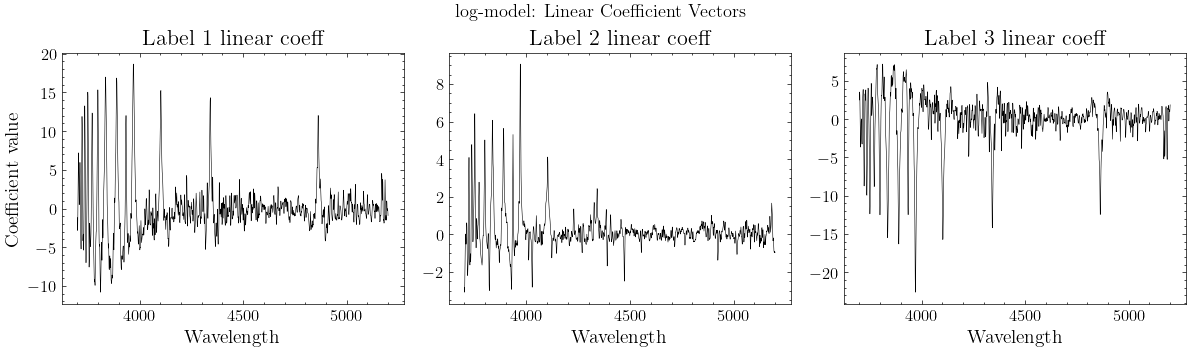

2026-03-23 16:24:04,588 [DEBUG] Couldn't get screen size. Progressbar may look odd.
stty: 'standard input'2026-03-23 16:24:04,589 [INFO] Running test step on 800 spectra
: Inappropriate ioctl for device


[====================================================================================================] 100% (5s)                               

=== log-model | training inversion diagnostics ===
MAE per label: [2.4727 3.1391 7.8686]
Pred sum mean +/- std: 14.169313 +/- 2.526458e+01
Distance to center (1/3,1/3,1/3): mean=12.9369, std=23.8742


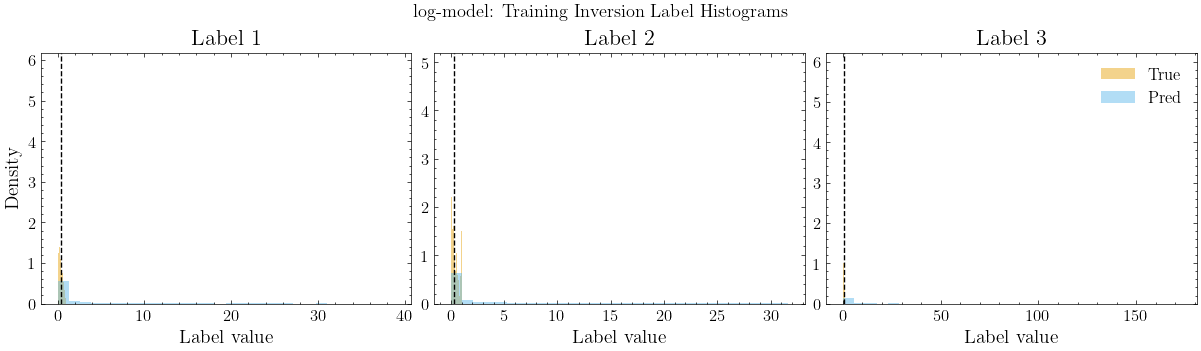


=== log-prior-model | coefficient diagnostics ===
Linear-term correlation matrix:
[[ 1.     0.759 -0.982]
 [ 0.759  1.    -0.817]
 [-0.982 -0.817  1.   ]]
cond(Theta_lin^T Theta_lin) = 1.860e+02


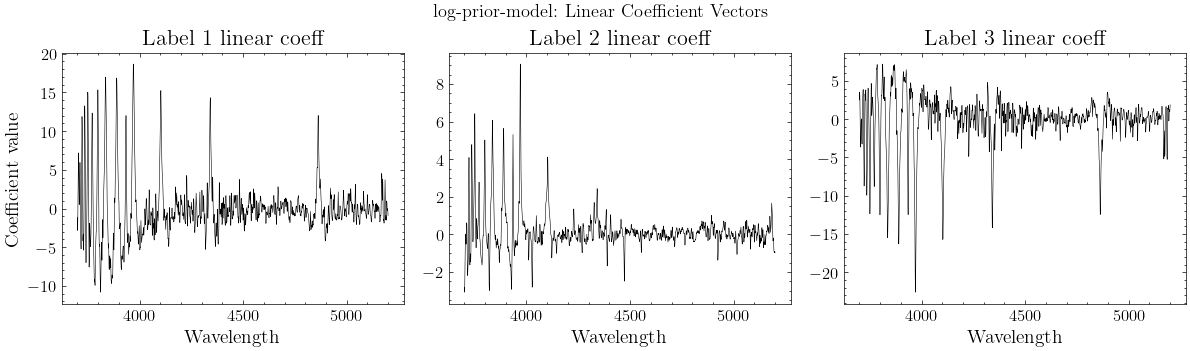

2026-03-23 16:24:14,547 [DEBUG] Couldn't get screen size. Progressbar may look odd.
stty: 'standard input'2026-03-23 16:24:14,548 [INFO] Running test step on 800 spectra
: Inappropriate ioctl for device


[====================================================================================================] 100% (6s)                               

=== log-prior-model | training inversion diagnostics ===
MAE per label: [ 61.5662  59.0084 133.5299]
Pred sum mean +/- std: 255.103868 +/- 4.646092e+02
Distance to center (1/3,1/3,1/3): mean=253.3354, std=465.2556


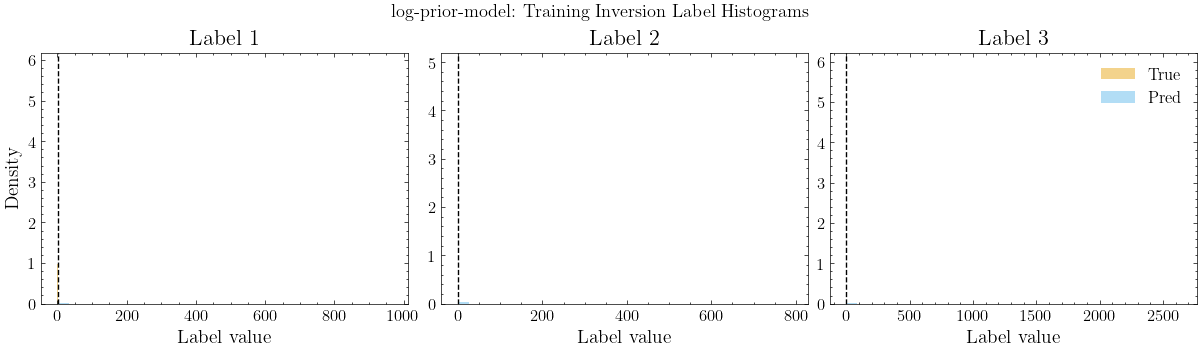


=== linear-model | coefficient diagnostics ===
Linear-term correlation matrix:
[[1.    0.895 0.895]
 [0.895 1.    1.   ]
 [0.895 1.    1.   ]]
cond(Theta_lin^T Theta_lin) = 4.998e+16


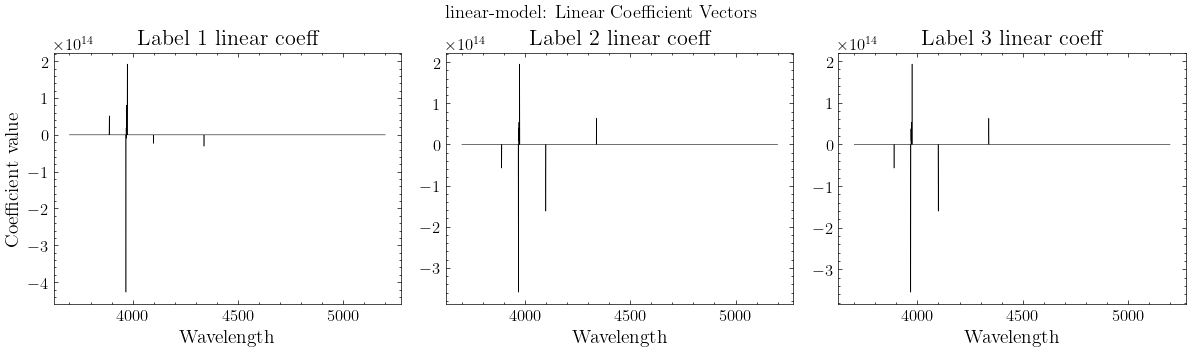

stty: 'standard input'2026-03-23 16:24:23,888 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-03-23 16:24:23,889 [INFO] Running test step on 800 spectra


[====================================================================================================] 100% (8s)                               

=== linear-model | training inversion diagnostics ===
MAE per label: [0.244  0.2635 0.2517]
Pred sum mean +/- std: 1.000000 +/- 1.013698e-15
Distance to center (1/3,1/3,1/3): mean=0.0692, std=0.0001


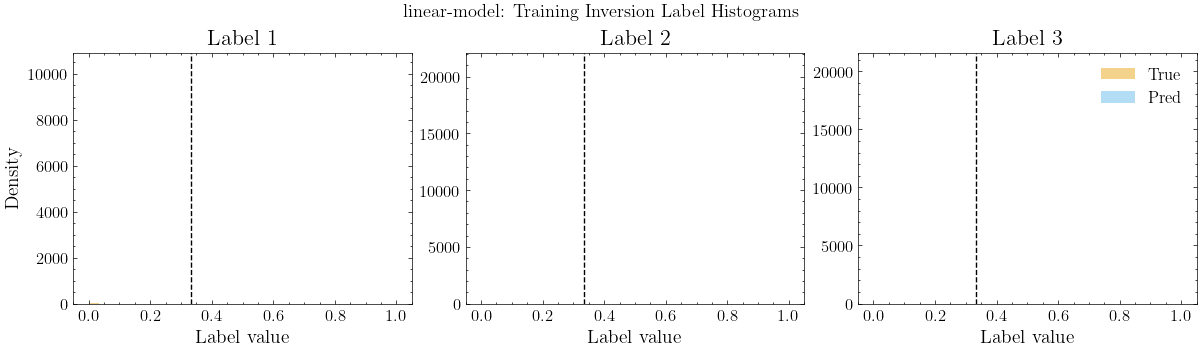


=== linear-prior-model | coefficient diagnostics ===
Linear-term correlation matrix:
[[1.    0.895 0.895]
 [0.895 1.    1.   ]
 [0.895 1.    1.   ]]
cond(Theta_lin^T Theta_lin) = 4.998e+16


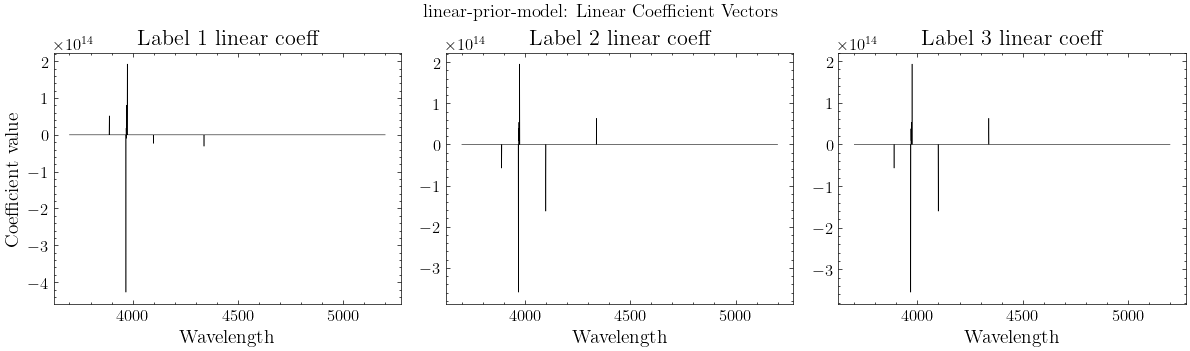

2026-03-23 16:24:38,244 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-03-23 16:24:38,245 [INFO] Running test step on 800 spectra
stty: 'standard input': Inappropriate ioctl for device

[=                                                                                                   ]   1% (10/800)                          

[====================================================================================================] 100% (16s)                              

=== linear-prior-model | training inversion diagnostics ===
MAE per label: [0.0049 0.0076 0.0037]
Pred sum mean +/- std: 1.000000 +/- 4.458206e-17
Distance to center (1/3,1/3,1/3): mean=0.4720, std=0.2052


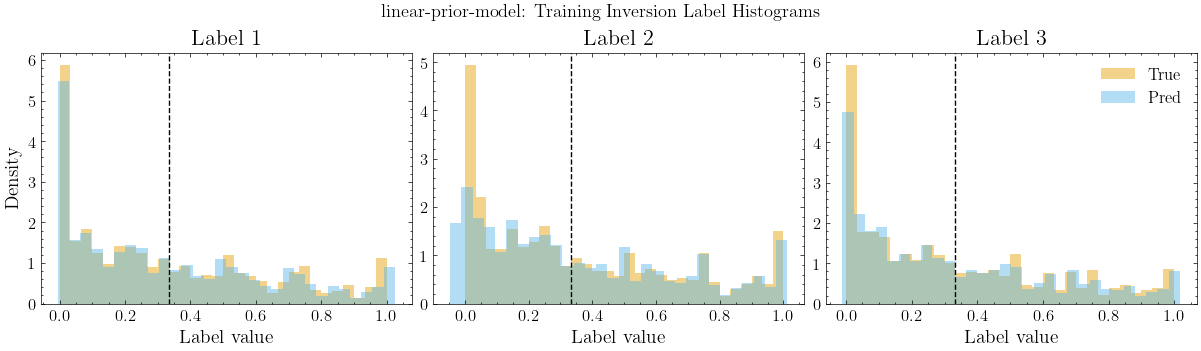

In [10]:
def diagnose_training_inversion(config_name, snr=default_snr, bins=30):
    """Run inversion on training spectra and check for center-collapse behavior."""
    cfg = CONFIGS[config_name]
    model = load_model(config_name, snr=snr)

    true_model_space = np.asarray(model.training_set_labels, dtype=float)
    flux = np.asarray(model.training_set_flux, dtype=float)
    ivar = np.asarray(model.training_set_ivar, dtype=float)

    # Use the same inverse constraints each config was trained/evaluated with.
    if config_name in ('linear-model', 'linear-bounds-model'):
        pred_model_space, *_ = model.test(flux, ivar, label_bounds=([0, 0, 0], [1, 1, 1]))
    elif config_name == 'log-prior-model':
        pred_model_space, *_ = model.test(flux, ivar, prior_sum_target=1, prior_sum_std=0.1)
    else:
        pred_model_space, *_ = model.test(flux, ivar)

    # Convert to linear label space for diagnostics.
    if cfg['model_labels_are_log10']:
        true_lin = np.power(10.0, true_model_space)
        pred_lin = np.power(10.0, pred_model_space)
    else:
        true_lin = true_model_space
        pred_lin = pred_model_space

    mae = np.mean(np.abs(pred_lin - true_lin), axis=0)
    sum_mean = np.mean(pred_lin.sum(axis=1))
    sum_std = np.std(pred_lin.sum(axis=1))
    center = np.array([1/3, 1/3, 1/3])
    center_dist = np.linalg.norm(pred_lin - center, axis=1)

    print(f"\n=== {config_name} | training inversion diagnostics ===")
    print(f"MAE per label: {np.array2string(mae, precision=4)}")
    print(f"Pred sum mean +/- std: {sum_mean:.6f} +/- {sum_std:.6e}")
    print(f"Distance to center (1/3,1/3,1/3): mean={center_dist.mean():.4f}, std={center_dist.std():.4f}")

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
    for i in range(3):
        ax[i].hist(true_lin[:, i], bins=bins, alpha=0.45, density=True, label='True')
        ax[i].hist(pred_lin[:, i], bins=bins, alpha=0.45, density=True, label='Pred')
        ax[i].axvline(1/3, color='k', linestyle='--', linewidth=1)
        ax[i].set_title(label_names[i])
        ax[i].set_xlabel('Label value')
    ax[0].set_ylabel('Density')
    ax[-1].legend(loc='best')
    fig.suptitle(f'{config_name}: Training Inversion Label Histograms')
    plt.show()


# Run diagnostics for all configs
for cfg_name in CONFIGS:
    diagnose_coefficients(cfg_name, snr=default_snr)
    diagnose_training_inversion(cfg_name, snr=default_snr)